<a href="https://colab.research.google.com/github/Krunchops/GPT_scratch/blob/main/attention_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import matplotlib.pyplot as plt
import tiktoken
from torch import nn
import torch.nn.functional as F
import numpy as np

In [3]:

class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps=1e-5
    self.shift=nn.Parameter(torch.zeros(emb_dim))
    self.scale=nn.Parameter(torch.ones(emb_dim))
  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True)
    norm_x=(x-mean)/torch.sqrt(var+self.eps)# i added eps to var to prevent division by zero during calculation of norm
    return self.scale*norm_x +self.shift  # self.scale and self.shift are parameters which the model can learn during training and set them to best values if possible
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*(1+ (torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+ 0.044715*torch.pow(x,3)))))
class FeedForward(nn.Module):
    def __init__(self, cfg):
      super().__init__()
      self.layers = nn.Sequential(
      nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
      GELU(),
      nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
)
    def forward(self, x):
      return self.layers(x)
class transformer(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(d_in=cfg["emb_dim"],d_out=cfg["emb_dim"],context_length=cfg["context_length"],num_heads=cfg["n_heads"],dropout=cfg["drop_rate"],qkv_bias=cfg["qkv_bias"])
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_residual=nn.Dropout(cfg["drop_rate"])
  def forward(self,x):
    residual=x  #ADDING RESIDUAL CONNECTIONS FOR BETTER OPTIMIZATIONS
    x=self.att(x)
    x=self.drop_residual(x)
    x=x+residual
    residual=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_residual(x)
    x=x+residual
    return x
class MultiHeadAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
    super().__init__()
    print("d_out must be divisible by num_heads")
    self.num_heads=num_heads
    self.d_out=d_out
    self.attn_weights=None #adding this
    self.dropout=nn.Dropout(dropout)
    self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.head_dim=d_out//num_heads
    self.out_proj = nn.Linear(d_out, d_out)
    self.register_buffer(
    "mask",
    torch.triu(torch.ones(context_length, context_length),
               diagonal=1))
  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
    queries=queries.view(b,num_tokens,self.num_heads,self.head_dim)
    values=values.view(b,num_tokens,self.num_heads,self.head_dim)
    keys=keys.transpose(1,2)
    values=values.transpose(1,2)
    queries=queries.transpose(1,2)
    attn_sc= queries @ keys.transpose(2,3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_sc.masked_fill_(mask_bool, -torch.inf)
    attn_weights=torch.softmax(attn_sc/self.head_dim**0.5,dim=-1)
    self.attn_weights = attn_weights.detach()
    attn_weights=self.dropout(attn_weights)
    context_vec=attn_weights @ values
    context_vec=context_vec.transpose(1,2)
    context_vec = context_vec.contiguous().view(
    b, num_tokens, self.d_out
)
    context_vec = self.out_proj(context_vec)
    return context_vec
class GPT(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks = nn.Sequential(
    *[transformer(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
    cfg["emb_dim"], cfg["vocab_size"], bias=False)
  def forward(self,in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(
    torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

In [9]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 128,          # Embedding dimension
    "n_heads": 2,           # Number of attention heads
    "n_layers": 2,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [8]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

In [10]:
model=GPT(GPT_CONFIG_124M)

d_out must be divisible by num_heads
d_out must be divisible by num_heads


In [16]:
model.load_state_dict(torch.load("/content/model.pt", map_location="cpu"))

<All keys matched successfully>

In [17]:
model.eval()

GPT(
  (tok_emb): Embedding(50257, 128)
  (pos_emb): Embedding(1024, 128)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): transformer(
      (att): MultiHeadAttention(
        (dropout): Dropout(p=0.1, inplace=False)
        (W_key): Linear(in_features=128, out_features=128, bias=False)
        (W_query): Linear(in_features=128, out_features=128, bias=False)
        (W_value): Linear(in_features=128, out_features=128, bias=False)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU()
          (2): Linear(in_features=512, out_features=128, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_residual): Dropout(p=0.1, inplace=False)
    )
    (1): transformer(
      (att): MultiHeadAttention(
        (dropout): Dropout(p=0.1, inplace=False)
    

In [18]:
text = "Hello GPT, this model understands attention"
tokens = enc.encode(text)

In [19]:
x = torch.tensor(tokens).unsqueeze(0)

In [20]:
with torch.no_grad():
    _ = model(x)

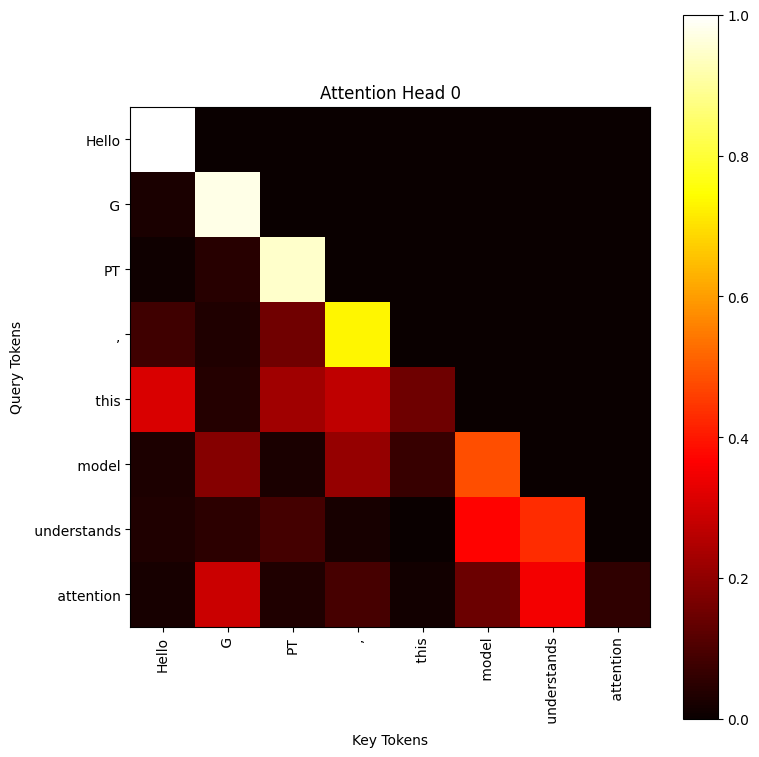

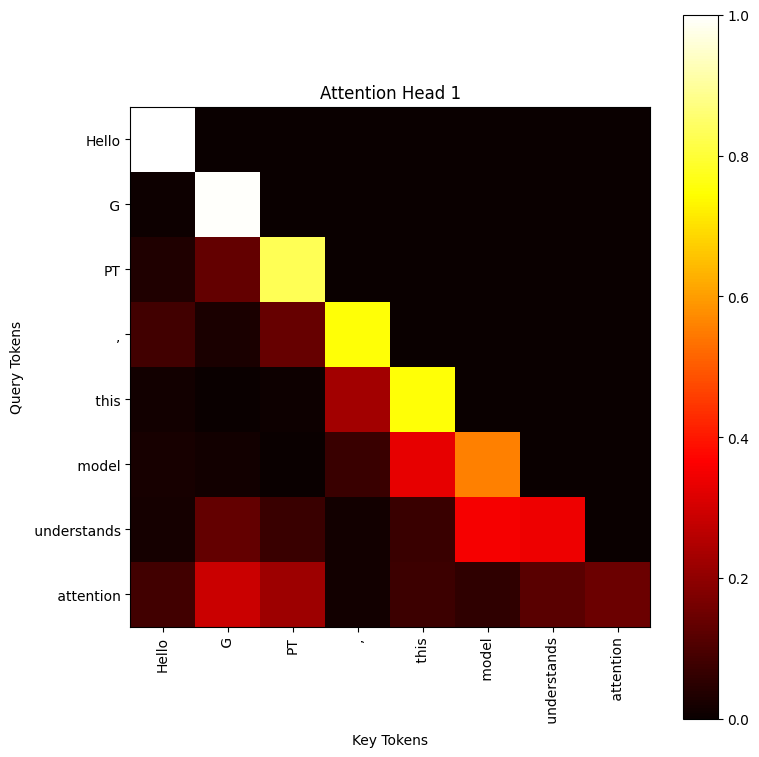

In [21]:
attn = model.trf_blocks[0].att.attn_weights
attn = attn[0]
decoded_tokens = [enc.decode([t]) for t in tokens]
def plot_head(attn_matrix, tokens, head_id):
    plt.figure(figsize=(8, 8))
    plt.imshow(attn_matrix.cpu(), cmap='hot')
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.colorbar()
    plt.title(f"Attention Head {head_id}")
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.tight_layout()
    plt.show()
num_heads = attn.shape[0]
for h in range(num_heads):
    plot_head(attn[h], decoded_tokens, h)